In [1]:
import sys
import os
import glob
from scipy import stats

import dabest

import numpy as np
import scipy as sp
import pandas as pd
import math
import decimal

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = 'Helvetica'
rcParams['font.size'] = 8 

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 28.95it/s]

Numba compilation complete!


In [2]:
specifiedpath = 'C:\\Users\\User\\'

filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Cell stainings\\MB247\\"
sum_csv = "ACR eOPN3 SUM Posterior vs Anterior.csv"

df= pd.read_csv(specifiedpath + filedir + sum_csv)

df = df.replace({"ACR1": "GtACR1", "eOPN3": "OPN3"}, regex=True)

df1 = df.iloc[0:36,0:5]
df1["Genotype_Position"] = df["Genotype"] + " " + df["Position"]

In [3]:
df1

,Genotype,Position,Expt,Value,ID,Genotype_Position
0,GtACR1,Posterior,MB247 GtACR1,81.141,1,GtACR1 Posterior
1,GtACR1,Posterior,MB247 GtACR1,59.530,2,GtACR1 Posterior
2,GtACR1,Posterior,MB247 GtACR1,107.151,3,GtACR1 Posterior
3,GtACR1,Posterior,MB247 GtACR1,94.261,4,GtACR1 Posterior
4,GtACR1,Posterior,MB247 GtACR1,88.247,5,GtACR1 Posterior
5,GtACR1,Posterior,MB247 GtACR1,101.927,6,GtACR1 Posterior
6,GtACR1,Posterior,MB247 GtACR1,82.013,7,GtACR1 Posterior
7,GtACR1,Posterior,MB247 GtACR1,100.925,8,GtACR1 Posterior
8,GtACR1,Anterior,MB247 GtACR1,79.610,1,GtACR1 Anterior
9,GtACR1,Anterior,MB247 GtACR1,68.592,2,GtACR1 Anterior


In [4]:
paired_delta2 = dabest.load(data = df1, x = ["Position", "Genotype"], y = "Value", delta2 = True, experiment = "Genotype", x1_level = ["Posterior", "Anterior"], paired = 'baseline', id_col = "ID" )
paired_delta2

DABEST v2025.03.27
                  
Good afternoon!
The current time is Tue Aug 18 15:26:53 2026.

Paired effect size(s) for repeated measures against baseline 
with 95% confidence intervals will be computed for:
1. Anterior GtACR1 minus Posterior GtACR1
2. Anterior OPN3 minus Posterior OPN3
3. OPN3 minus GtACR1 (only for mean difference)

5000 resamples will be used to generate the effect size bootstraps.

In [ ]:
palette = { 'GtACR1':'deeppink', 'OPN3' : 'teal'}
genoListNL = [ 'GtACR1','OPN3']

compare = paired_delta2.hedges_g.plot(fontsize_rawxlabel=9,fontsize_contrastxlabel= 9,  color_col='Genotype', custom_palette=palette,  raw_desat=1, contrast_desat=1);

ax_raw = compare.axes[0]

for line in ax_raw.lines:
    xdata = line.get_xdata()
    if len(xdata) == 2:
        if xdata[0] < 1.5:
            line.set_color('deeppink')
        else:
            line.set_color('teal')

colors = [palette[g] for g in genoListNL]
violins = [c for c in compare.axes[1].collections if isinstance(c, mpl.collections.PolyCollection)]

for violin, c in zip(violins, colors):
    violin.set_color(c)

for txt, c in zip(compare.axes[1].texts, colors):
    txt.set_color(c)

for patch, c in zip(compare.axes[1].patches, colors):
    patch.set_color(c)

compare.axes[0].set_xticklabels(["P", "A",
                              "P", "A",])
compare.axes[0].set_ylabel('Mean Intensity (a.u.)')
compare.axes[1].set_ylabel('Mean Diff (a.u.)')
compare.axes[0].get_legend().remove()
compare.axes[1].spines['bottom'].set_visible(False)
compare.axes[1].set_xticks([0.5, 2.5])
compare.axes[1].set_xticklabels('')
compare.axes[1].set_xticklabels(genoListNL, fontsize = 9)

plt.show()
#compare.savefig('MB247GtACR1 OPN3.png', dpi = 300)
#compare.savefig('MB247GtACR1 OPN3.svg')

In [ ]:
palette = { 'GtACR1':'deeppink', 'OPN3' : 'teal'}
genoListNL = [ 'GtACR1','OPN3']

compare = paired_delta2.mean_diff.plot(fontsize_rawxlabel=9,fontsize_contrastxlabel= 9,  color_col='Genotype', custom_palette=palette,  raw_desat=1, contrast_desat=1);

ax_raw = compare.axes[0]

for line in ax_raw.lines:
    xdata = line.get_xdata()
    if len(xdata) == 2:
        if xdata[0] < 1.5:
            line.set_color('deeppink')
        else:
            line.set_color('teal')

colors = [palette[g] for g in genoListNL]
violins = [c for c in compare.axes[1].collections if isinstance(c, mpl.collections.PolyCollection)]

for violin, c in zip(violins, colors):
    violin.set_color(c)

for txt, c in zip(compare.axes[1].texts, colors):
    txt.set_color(c)

for patch, c in zip(compare.axes[1].patches, colors):
    patch.set_color(c)

compare.axes[0].set_xticklabels(["P", "A",
                              "P", "A",])
compare.axes[0].set_ylabel('Mean Intensity (a.u.)')
compare.axes[1].set_ylabel('Mean Diff (a.u.)')
compare.axes[0].get_legend().remove()
compare.axes[1].spines['bottom'].set_visible(False)
compare.axes[1].set_xticks([0.5, 2.5])
compare.axes[1].set_xticklabels('')
compare.axes[1].set_xticklabels(genoListNL, fontsize = 9)

plt.show()
#compare.savefig('MB247GtACR1 OPN3.png', dpi = 300)
#compare.savefig('MB247GtACR1 OPN3.svg')

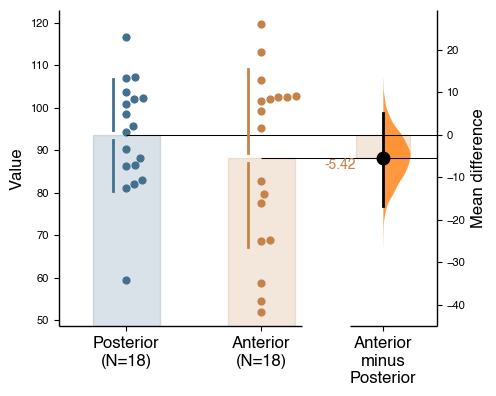

In [7]:
paired_delta2 = dabest.load(data = df1,  y = "Value", x = "Position", idx = ["Posterior", "Anterior"] )
paired_delta2.mean_diff.plot();